In [1]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from pathlib import Path
from sklearn.decomposition import PCA
from scipy.sparse import hstack
from tqdm import tqdm
from IPython.display import display

In [2]:
def richness_features(text: str):
    words = [w.lower() for w in text.split()]
    N = len(words) or 1
    counts = Counter(words)
    V = len(counts)
    freq = np.array(list(counts.values()))
    hapax1 = np.sum(freq == 1)
    hapax2 = np.sum(freq == 2)
    yule_k = 1e4 * (np.sum(freq**2) - N) / (N**2)
    denom = 1 - hapax1 / N
    if denom == 0:
        denom = 1e-6
    honore_r = 100 * np.log(N) / denom
    return np.array([V / N, hapax1, hapax2, yule_k, honore_r])


def preprocessing(
    train_texts: list[str], test_texts: list[str], ngram_range: tuple[int, int] = (3, 5)
):
    vectorizer = CountVectorizer(
        analyzer="char", ngram_range=ngram_range, lowercase=True, min_df=1
    )
    X_train_ngrams = vectorizer.fit_transform(train_texts)
    X_test_ngrams = vectorizer.transform(test_texts)

    X_train_rich = np.vstack([richness_features(t) for t in train_texts])
    X_test_rich = np.vstack([richness_features(t) for t in test_texts])

    X_train = hstack([X_train_ngrams, X_train_rich])
    X_test = hstack([X_test_ngrams, X_test_rich])

    scaler = StandardScaler(with_mean=False)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, vectorizer

In [3]:
def load_train_data(dataset_dir: Path) -> tuple[list[str], list[str]]:
    train_texts, train_labels = [], []
    train_path = dataset_dir / "train"

    const_len_to_trim = len("12Ctrain")
    for file_path in sorted(train_path.glob("12Ctrain*.txt")):
        name = file_path.stem
        label = name[const_len_to_trim : const_len_to_trim + 1]
        with file_path.open(encoding="utf-8") as f:
            train_texts.append(f.read())
            train_labels.append(label)
    return train_texts, train_labels


def load_test_data(dataset_dir: Path) -> list[str]:
    test_texts = []
    test_path = dataset_dir / "test"
    for file_path in sorted(test_path.glob("12Ctest*.txt")):
        with file_path.open(encoding="utf-8") as f:
            test_texts.append(f.read())
    return test_texts

In [4]:
def encode_labels(
    labels: list[str],
) -> tuple[NDArray[np.int64], dict[str, np.int64], dict[np.int64, str]]:
    unique_labels = sorted(set(labels))
    label2id: dict[str, np.int64] = {
        lbl: np.int64(idx) for idx, lbl in enumerate(unique_labels)
    }
    id2label: dict[np.int64, str] = {idx: lbl for lbl, idx in label2id.items()}
    encoded: NDArray[np.int64] = np.array([label2id[lbl] for lbl in labels])
    return encoded, label2id, id2label

In [5]:
dataset_dir = Path("dataset")
train_texts, train_labels = load_train_data(dataset_dir)
test_texts = load_test_data(dataset_dir)
X_train, X_test, vectorizer = preprocessing(train_texts, test_texts)
y_train, label2id, id2label = encode_labels(train_labels)
y_test = np.array([label2id[lbl] for lbl in ["C", "E", "A", "F", "H", "B", "G", "D"]])

In [6]:
models = {
    "SVM": SVC(kernel="linear", probability=True),
    "DecisionTree": DecisionTreeClassifier(criterion="entropy"),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "LogReg": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
}

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_test, y_test, epochs=10, lr=1e-3):
    model = MLP(input_dim=X_train.shape[1], num_classes=len(np.unique(y_train)))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    X_train_t = torch.tensor(X_train.todense(), dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test.todense(), dtype=torch.float32)

    for epoch in tqdm(range(epochs)):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        preds = torch.argmax(model(X_test_t), dim=1).numpy()
    return preds

In [8]:
results = []
all_preds = {}
all_labels = y_test

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))
    all_preds[name] = preds

mlp_preds = train_mlp(X_train, y_train, X_test, y_test)
acc_mlp = accuracy_score(y_test, mlp_preds)
results.append(("MLP", acc_mlp))
all_preds["MLP"] = mlp_preds

100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 10.11it/s]


/SASTRA-NEW-CLUSTER/users/akilan/authorship_id/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/SASTRA-NEW-CLUSTER/users/akilan/authorship_id/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/SASTRA-NEW-CLUSTER/users/akilan/authorship_id/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

=== SVM REPORT ===
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.20      1.00      0.33         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.25         8
   macro avg       0.07      0.25      0.10         8
weighted avg       0.07      0.25      0.10         8



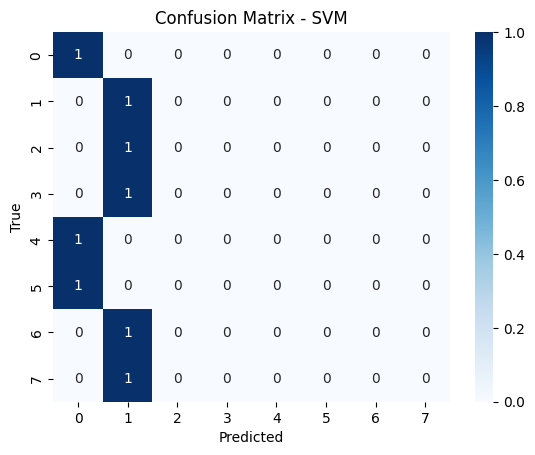

In [9]:
# print classification report for one model (SVM as example)
print("=== SVM REPORT ===")
print(classification_report(y_test, all_preds["SVM"]))

# confusion matrix (SVM example)
cm = confusion_matrix(y_test, all_preds["SVM"])
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

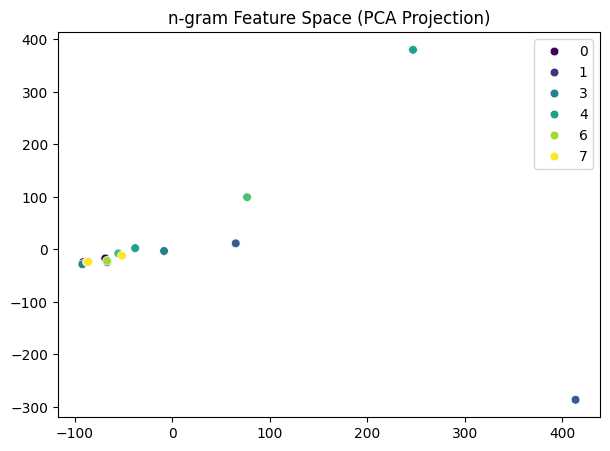

In [10]:
X_vis = X_train[:200]
y_vis = y_train[:200]

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_vis)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=y_vis, palette="viridis", s=40)
plt.title("n-gram Feature Space (PCA Projection)")
plt.show()

In [11]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
df_results = df_results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(df_results)

,Model,Accuracy
0,LogReg,0.750
1,KNN,0.625
2,DecisionTree,0.250
3,SVM,0.250
4,RandomForest,0.250
5,MLP,0.250
